In [1]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from scipy.stats import chi2, kstwobign, norm
from math import gcd
from sympy import primefactors
from itertools import product
from itertools import product, islice

In [2]:
def histogram(x, bins=10, text="Histogram of randomly generated numbers by LGC"):
    plt.hist(x, bins=bins)
    plt.title(text)
    plt.show()
    
    

## Exercise 1


In [3]:
def linear_congruential_generator(x0, a, c, M, n = 10000):
    n_array = np.zeros(n, dtype=np.int32)
    n_array[0] = x0 % M
    
    for i in range(1, n):
        n_array[i] = (a * n_array[i-1] + c) % M
    
    return n_array

def hull_dobell(a, c, M):
    # Condition 1
    cond1 = gcd(M, c) == 1
    
    # Condition 2
    primes = primefactors(M)
    cond2 = all((a - 1) % p == 0 for p in primes)
    
    # Condition 3
    cond3 = ((M % 4 != 0) or ((a - 1) % 4 == 0))
    
    return cond1 and cond2 and cond3
        

In [4]:
def chi_square_test(x, M):
    n = len(x)
    df = M - 1
    p_i = 1 / M
    
    n_observed = np.bincount(x, minlength=M)
    n_expected = (n * p_i) * np.ones(M)
    T = np.sum((n_observed - n_expected) **2 / n_expected)
    p_value = 1 - chi2.cdf(T, df)
        
    return T, p_value


def kolmogorov_smirnov_test(x, M):
    n = len(x)
    p_i = 1 / M
    
    F_n_x = np.cumsum(np.bincount(x, minlength=M)) / n #Empircal cdf

    F_x = np.cumsum(p_i * np.ones(M)) # Theoretical CDF (uniform)
    
    D_n = np.max(np.abs(F_n_x - F_x)) # KS statistic
    p_value = kstwobign.sf(np.sqrt(n) * D_n)
    
    return D_n, p_value
    
    
def run_test_1(x):
    median = np.median(x)
    signs = x > median
    
    T = 1 # Test statistc / total number of runs
    for i in range(1, len(signs)):
        if signs[i] == signs[i-1]:
            continue
        else:
            T += 1
        
    n1 = np.sum(signs)
    n2 = len(x) - n1
    
    mu_p = 2 * (n1*n2 / (n1 + n2)) + 1
    sigma_p = 2*n1*n2*(2*n1*n2 - n1 - n2) / ((n1+n2)**2 * (n1+n2-1))
    
    p_value = 1- norm.cdf(T, loc=mu_p, scale=sigma_p )
    
    return T, p_value
    
def correlation_test(x, h_max=3, print_values=False):
    x = np.array(x)
    correlations = np.zeros(h_max + 1)
    
    for h in range(0, h_max + 1):
        if h == 0:
            correlations[0] = 1.0 
        else:
            correlations[h] = np.corrcoef(x[:-h], x[h:])[0, 1]
    
    if print_values:
        for h, c in enumerate(correlations):
            print(f"Lag {h}: {c:.4f}")
    
    return correlations
    
    
    
    
    
    
    
    

In [5]:
def statistical_properties(x, M, bins=10):
    histogram(x, bins=bins)
    print(f"Range: [{np.min(x)},{np.max(x)}]")
    print("Mean:", np.mean(x))
    print(f"Standard deviation: {np.std(x):.3f}")
    print(chi_square_test(x, M))
    print(kolmogorov_smirnov_test(x, M))
    print(run_test_1(x))
    correlation_test(x, print_values=True)
    

True


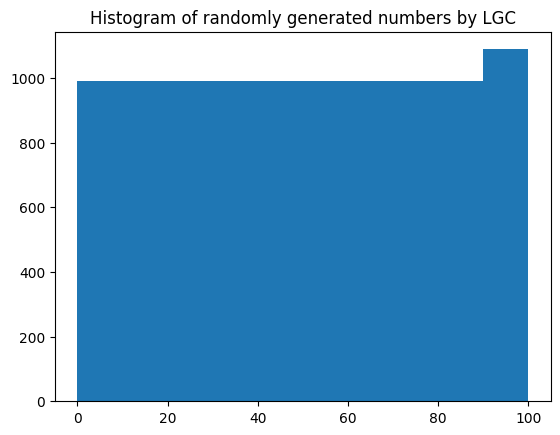

Range: [0,100]
Mean: 49.996
Standard deviation: 29.156
(np.float64(0.010000000000000007), np.float64(1.0))
(np.float64(8.910891089110307e-05), np.float64(1.0))
(1783, np.float64(0.9010201468208543))
Lag 0: 1.0000
Lag 1: 0.5129
Lag 2: 0.1210
Lag 3: -0.1753


In [6]:
x0, a, c, M = 10, 102, 9, 101
print(hull_dobell(a, c, M))

U_i = linear_congruential_generator(x0, a, c, M, n = 10000)
statistical_properties(U_i, M, bins=10)


/var/folders/2w/hnlzx3jn2652kr04m9mgwt540000gp/T/ipykernel_59953/2967664862.py:21: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


<Figure size 1200x500 with 0 Axes>

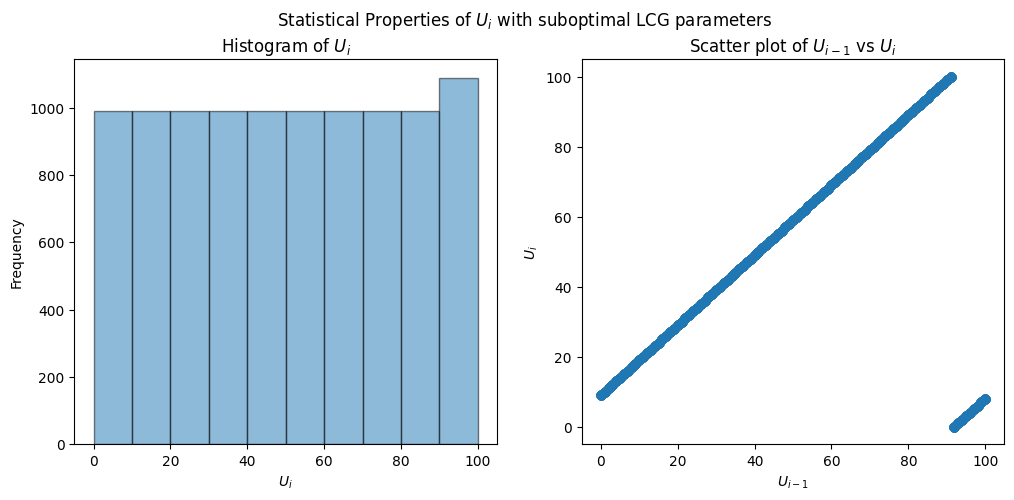

In [7]:

plt.figure(figsize=(12, 5))
fig, ax = fig, axs = plt.subplots(1, 2, figsize=(12, 5))



ax[0].hist(U_i, bins=10, alpha=0.5, histtype='bar', ec='black')
ax[0].set_title("Histogram of $U_i$")
ax[0].set_xlabel("$U_i$")
ax[0].set_ylabel("Frequency")

U_i_lagged = U_i[1:]
U_i_original = U_i[:-1]
ax[1].scatter(U_i_original, U_i_lagged, alpha=0.5)
ax[1].set_title("Scatter plot of $U_{i-1}$ vs $U_i$")
ax[1].set_xlabel("$U_{i-1}$")
ax[1].set_ylabel("$U_i$")


fig.suptitle('Statistical Properties of $U_i$ with suboptimal LCG parameters')

fig.show()



In [8]:
a_values = np.arange(10**2, 10**3)[::-1]
c_values = np.arange(10**2, 10**3)[::-1]
M_values = np.arange(10**2, 10**3)[::-1]

parameter_grid = list(islice(
    ((a, c, M) 
     for a, c, M in product(a_values, c_values, M_values)
     if hull_dobell(a, c, M)),
    10
))

Testing parameters: a=999, c=993, M=499


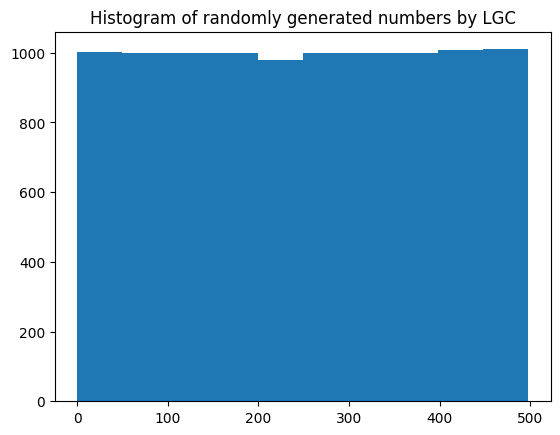

Range: [0,498]
Mean: 249.3571
Standard deviation: 144.197
(np.float64(0.9580000000000003), np.float64(1.0))
(np.float64(0.0015232464929866296), np.float64(1.0))
(202, np.float64(0.972557915656503))
Lag 0: 1.0000
Lag 1: 0.9401
Lag 2: 0.8820
Lag 3: 0.8251


In [9]:
# Test the first parameter set
a, c, M = parameter_grid[-1]
print(f"Testing parameters: a={a}, c={c}, M={M}")
x = linear_congruential_generator(1, a, c, M)
statistical_properties(x, M, bins=10)

## Exercise 2

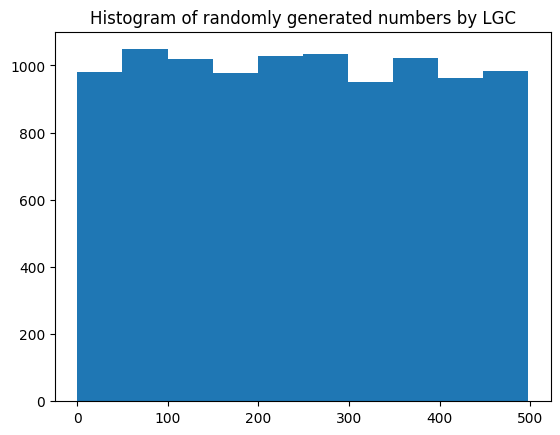

Range: [0,498]
Mean: 247.1922
Standard deviation: 143.370
(np.float64(560.2372), np.float64(0.027661120375968573))
(np.float64(0.011685771543085699), np.float64(0.13025327548650317))
(4960, np.float64(0.5065398753243567))
Lag 0: 1.0000
Lag 1: 0.0008
Lag 2: -0.0059
Lag 3: -0.0069


In [10]:
rng = np.random.default_rng(seed=42)
x_random = rng.integers(0, M, size=10000)
statistical_properties(x_random, M)
